For entropy with split of 0.25 we got  70.83%  
For entropy with split of 0.20 we got  74.02%  
For entropy with split of 0.30 we got 69.26%

For gini with split of 0.25 we got  69.79%  
For gini with split of 0.20 we got  72.07%  
For gini with split of 0.30 we got  67.09% 

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [96]:
dataset = pd.read_csv('../DATA/diabetes.csv')

X = dataset.iloc[ : , 0:7].values
Y = dataset.iloc[ : , -1].values

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.30, random_state = 0)

In [98]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [99]:
from sklearn.tree import DecisionTreeClassifier
#classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
classifier.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [100]:
Y_pred = classifier.predict(X_test)

In [101]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
cm

array([[118,  39],
       [ 37,  37]])

In [102]:
Accuracy = (cm[0][0] + cm[1][1])/(cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1])
Accuracy

np.float64(0.670995670995671)

In [103]:
from sklearn import metrics
prediction = metrics.accuracy_score(Y_test, Y_pred)
print("Accuracy:", prediction * 100 ,"%")

Accuracy: 67.09956709956711 %


In [104]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76       157
           1       0.49      0.50      0.49        74

    accuracy                           0.67       231
   macro avg       0.62      0.63      0.62       231
weighted avg       0.67      0.67      0.67       231



In [105]:
new_individual = np.array([[2, 120, 70, 20, 79, 25.0, 0.35]])

new_individual_scaled = sc.transform(new_individual)

new_predection = classifier.predict(new_individual_scaled)

if new_predection[0] == 1:
    print("the patient has diabetes")
    
else:
    print("the patient dont have diabetes")    

the patient dont have diabetes


[Text(0.532668500687758, 0.9705882352941176, 'x[1] <= 0.713\ngini = 0.462\nsamples = 537\nvalue = [343, 194]'),
 Text(0.29504814305364513, 0.9117647058823529, 'x[5] <= -0.723\ngini = 0.368\nsamples = 412\nvalue = [312, 100]'),
 Text(0.41385832187070154, 0.9411764705882353, 'True  '),
 Text(0.13067400275103164, 0.8529411764705882, 'x[2] <= 1.251\ngini = 0.056\nsamples = 105\nvalue = [102, 3]'),
 Text(0.09766162310866575, 0.7941176470588235, 'x[1] <= 0.34\ngini = 0.039\nsamples = 100\nvalue = [98, 2]'),
 Text(0.06464924346629987, 0.7352941176470589, 'x[6] <= 0.611\ngini = 0.022\nsamples = 90\nvalue = [89, 1]'),
 Text(0.05364511691884457, 0.6764705882352942, 'gini = 0.0\nsamples = 77\nvalue = [77, 0]'),
 Text(0.07565337001375516, 0.6764705882352942, 'x[6] <= 0.701\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.06464924346629987, 0.6176470588235294, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.08665749656121045, 0.6176470588235294, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]

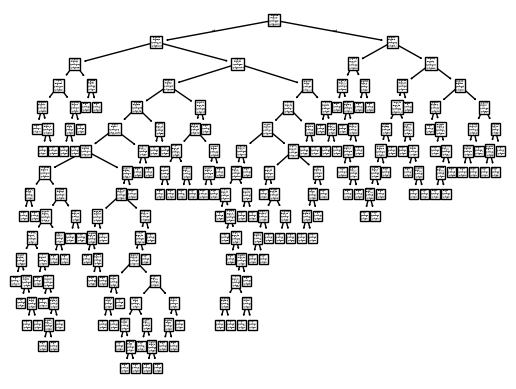

In [106]:
from sklearn import tree
tree.plot_tree(classifier)